## Part 2: RFM Segmentation

The segmentation method used here follows a similar approach from a research paper,
[Data mining for the online retail industry: A case study of RFM model-based customer
segmentation using data mining](https://link.springer.com/article/10.1057/dbm.2012.17)
(Chen, Sain & Guo).

### 1. Setup and import


In [34]:
import pandas as pd
from sqlalchemy import create_engine, URL
from dotenv import load_dotenv
import os

load_dotenv()


True

In [35]:
db_url = URL.create(
    "postgresql+psycopg2",
    username=os.getenv("DB_USERNAME"),
    password=os.getenv("SUPABASE_DB_PASSWORD"),
    host="aws-1-eu-west-1.pooler.supabase.com",
    port=5432,
    database="postgres",
)
engine = create_engine(db_url)

### 2. Load RFM aggregates from SQL

Recency, Frequency, and Monetary computed per customer:
- **Recency**: days since each customer's most recent transaction
- **Frequency**:  count of distinct transactions per customer
- **Monetary**: total spend per customer


In [36]:
rfm_query = """

SELECT
    customer_id,
    MAX(invoice_date) AS last_purchase_date,
    COUNT(DISTINCT invoice_no) AS frequency,
    SUM(total_price) AS monetary
FROM retail_orders
GROUP BY customer_id;
"""

rfm_df = pd.read_sql(rfm_query, engine)
rfm_df.info()
rfm_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         4338 non-null   int64         
 1   last_purchase_date  4338 non-null   datetime64[us]
 2   frequency           4338 non-null   int64         
 3   monetary            4338 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(2)
memory usage: 135.7 KB


,customer_id,last_purchase_date,frequency,monetary
0,12346,2011-01-18 10:01:00,1,77183.60
1,12347,2011-12-07 15:52:00,7,4310.00
2,12348,2011-09-25 13:13:00,4,1797.24
3,12349,2011-11-21 09:51:00,1,1757.55
4,12350,2011-02-02 16:01:00,1,334.40


Calculate recency

In [37]:
reference_date = rfm_df['last_purchase_date'].max() + pd.Timedelta(days=1)
rfm_df['recency'] = (reference_date - rfm_df['last_purchase_date']).dt.days
rfm_df = rfm_df.drop(columns=['last_purchase_date'])
rfm_df.head()

,customer_id,frequency,monetary,recency
0,12346,1,77183.60,326
1,12347,7,4310.00,2
2,12348,4,1797.24,75
3,12349,1,1757.55,19
4,12350,1,334.40,310


### 3. Score R, F, M

Each metric is split into quartiles (1–4) using `pd.qcut()`. Recency is scored in
reverse — a lower "days since" value is better, so it gets the higher score.
Frequency and Monetary score normally — higher value, higher score.

In [38]:
# checking unique values
print(rfm_df['recency'].nunique(),len(rfm_df))
print(rfm_df['frequency'].nunique(), len(rfm_df))
print(rfm_df['monetary'].nunique(), len(rfm_df))

349 4338
59 4338
4236 4338


In [39]:
rfm_df['R_score'] = pd.qcut(rfm_df['recency'].rank(method='first'), q=4, labels=[4, 3, 2, 1])
rfm_df['F_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm_df['M_score'] = pd.qcut(rfm_df['monetary'].rank(method='first'), q=4, labels=[1, 2, 3, 4])

rfm_df = rfm_df.set_index('customer_id')
rfm_df.head()

,frequency,monetary,recency,R_score,F_score,M_score
customer_id,,,,,,
12346,1,77183.60,326,1,1,4
12347,7,4310.00,2,4,4,4
12348,4,1797.24,75,2,3,4
12349,1,1757.55,19,3,1,4
12350,1,334.40,310,1,1,2


### 4. Combine into RFM segments

The quartile scores combine into a segment label using a rule-based mapping on the R/F/M score combination.

In [41]:
def segment_customer(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']

    if r == 4 and f == 4 and m == 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r == 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f <= 2 and m <= 2:
        return 'Promising'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f == 4 and m == 4:
        return 'Cannot Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Needs Attention'


rfm_df['segment'] = rfm_df.apply(segment_customer, axis=1)

rfm_df.head()

,frequency,monetary,recency,R_score,F_score,M_score,segment
customer_id,,,,,,,
12346,1,77183.60,326,1,1,4,Needs Attention
12347,7,4310.00,2,4,4,4,Champions
12348,4,1797.24,75,2,3,4,At Risk
12349,1,1757.55,19,3,1,4,Needs Attention
12350,1,334.40,310,1,1,2,Lost


In [46]:
rfm_df["segment"].value_counts().index

Index(['Lost', 'Loyal Customers', 'Needs Attention', 'Champions', 'At Risk',
       'Promising', 'New Customers'],
      dtype='str', name='segment')

### 5. Visualize segment distribution

Distribution of customers across segments, and how R/F/M relate to each other
(e.g. Frequency vs Monetary).

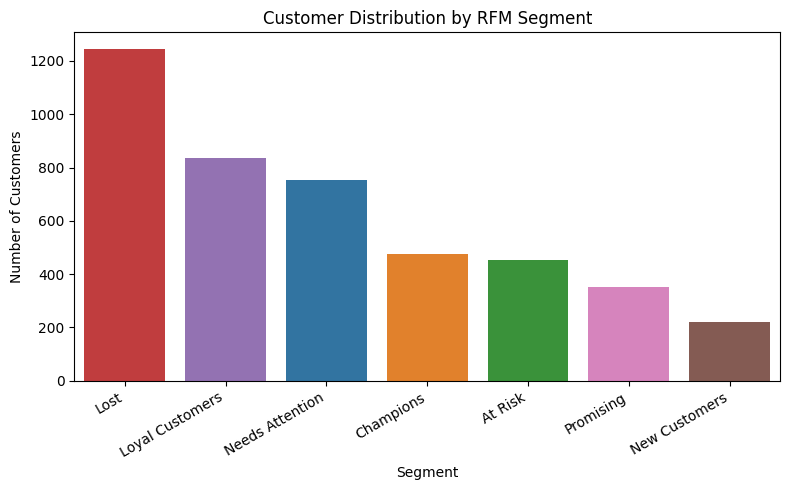

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Segment distribution — bar chart, ordered by count
segment_order = rfm_df['segment'].value_counts().index

plt.figure(figsize=(8, 5))
sns.countplot(data=rfm_df, x='segment', order=segment_order, hue='segment')
plt.title('Customer Distribution by RFM Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

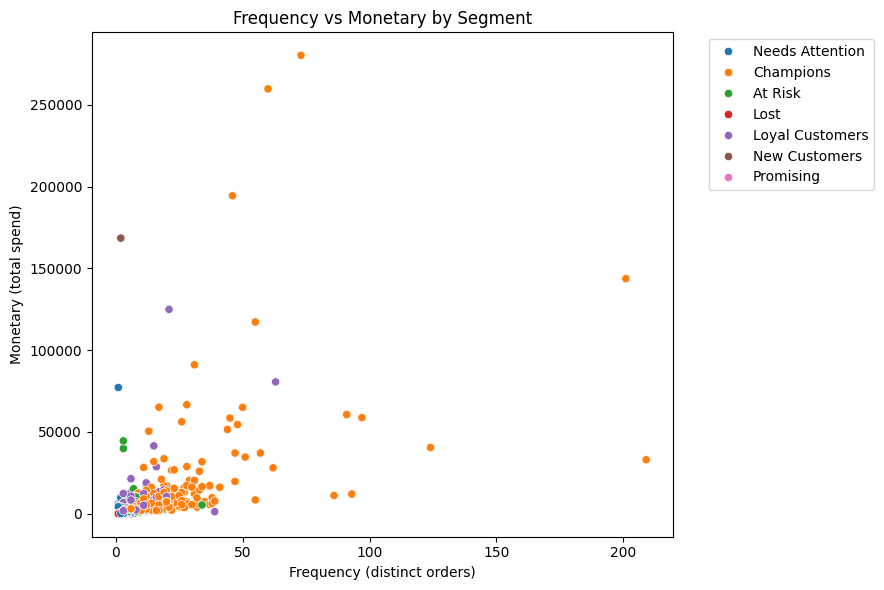

In [67]:
# 2. Frequency vs Monetary, colored by segment
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=rfm_df,
    x='frequency',
    y='monetary',
    hue='segment'
)
plt.title('Frequency vs Monetary by Segment')
plt.xlabel('Frequency (distinct orders)')
plt.ylabel('Monetary (total spend)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

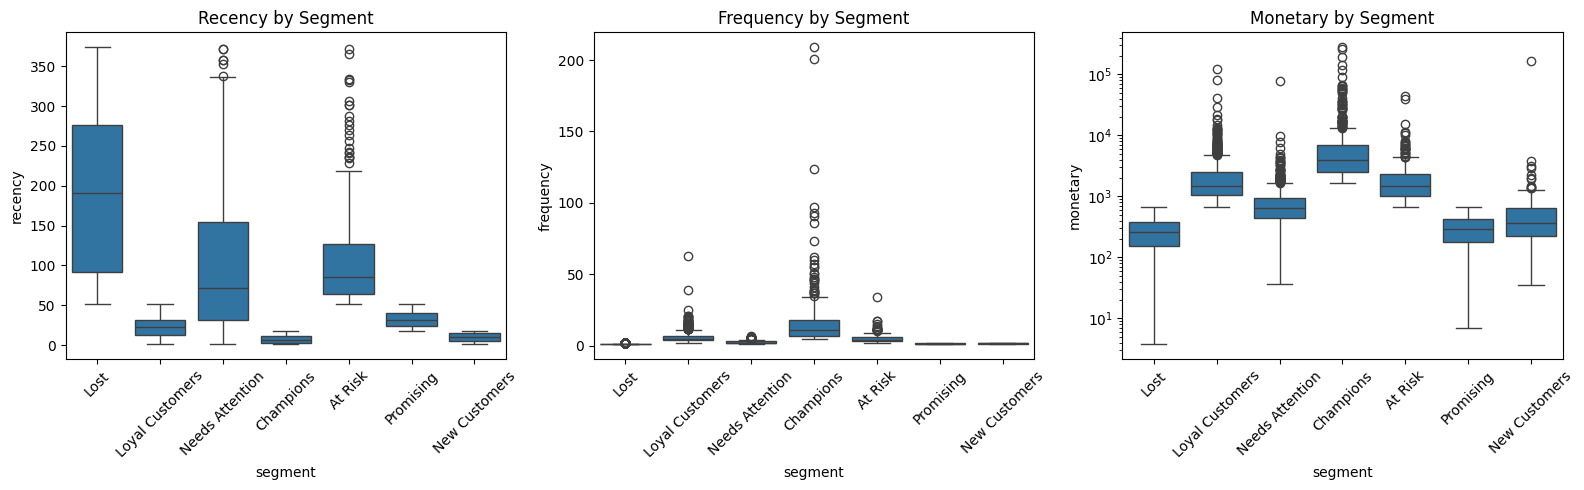

In [70]:
# 3. R, F, M distributions by segment
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=rfm_df, x='segment', y='recency', ax=axes[0], order=segment_order)
axes[0].set_title('Recency by Segment')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=rfm_df, x='segment', y='frequency', ax=axes[1], order=segment_order)
axes[1].set_title('Frequency by Segment')
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(data=rfm_df, x='segment', y='monetary', ax=axes[2], order=segment_order)
axes[2].set_title('Monetary by Segment')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

### **Findings**

**Segment sizes**  
- Lost is the biggest group (1,245 customers, almost 29% of all customers). Champions, the most valuable segment, is much smaller (477).

**Frequency vs Monetary**  
- Champions stand clearly apart, high frequency and high spend, including a few extreme outliers spending over 250,000. Every other segment clusters near the bottom left with little overlap, showing clean separation between segments.  
- Champions lead on both by a wide margin. Lost has the lowest spend and frequency of any segment. Needs Attention and At Risk sit in between, but with wide spread, meaning these are mixed groups, not uniform ones.

**Recency**  
- Champions and New Customers bought most recently (under 10 days median). Lost customers haven't purchased in a long time (median around 190 days).


**Conclusion**  
Champions are a small, clearly distinct high-value group, and Lost is the largest and weakest segment across all three metrics. The middle segments would need more granular analysis before acting on them i.e., further clustering with KMeans algorithm.